---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Vectorization Node Documentation</strong></center>
</div>

---

This Jupyter Notebook will walk you through the second step in iris recognition, `vectorization`, and does this through the `iris.nodes.vectorization` node. From it you will learn how to: 
- Initialize geometry refinement components for iris boundary processing.
- Apply contour interpolation to improve boundary continuity.
- Filter noisy contour points based on eyeball distance constraints.
- Smooth refined contours for more stable geometry representation.
- Use edge detection (Canny) to approximate iris boundaries.
- Prepare boundary information for downstream processing steps.

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>ContouringAlgorithm</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: vectorization</font>
    algorithm:    
      class_name: <font color='blue'>iris.ContouringAlgorithm</font>
      params: {}     
<code>   inputs:
      - name: geometry_mask
        source_node: segmentation_binarization
        index: 0
    callbacks:</code>

### What it does
`ContouringAlgorithm` converts segmentation masks into vectorized contour representations. It extracts the boundaries of the pupil, iris, and eyeball by tracing their edges and returning them as polygon coordinate arrays. These contours are used in later stages for geometric refinement and normalization.

In other words it uses filter functions to clean up the contours (removing noise or bad shapes)

**Key parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `contour_filters` | `List[Callable[[List[np.ndarray]], List[np.ndarray]]]` | [ContouringAlgorithm.filter_polygon_areas] | Filters out noisy or invalid contour shapes from the detected contours |

**Code \& Visualization Cells**

In [62]:
# ---- Imports ----
from iris.nodes.vectorization.contouring import ContouringAlgorithm

# ---- ContouringAlgorithm ----
node = ContouringAlgorithm()
print(node)

### What to Look For
The above code initializes the `ContouringAlgorithm` node. This node is responsible for extracting contour boundaries from the segmentation masks of the pupil, iris, and eyeball.

A successful run of the `ContouringAlgorithm` node should produce polygon contour representations of the pupil, iris, and eyeball regions. These contours are returned as arrays of coordinate points outlining the boundaries of each region.

Good output will contain smooth, continuous contours that closely follow the edges of the segmented regions. Poor output may contain fragmented contours, missing boundaries, or irregular shapes caused by noise in the segmentation mask.

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>ContouringInterpolation</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: interpolation</font>
    algorithm:    
      class_name: <font color='blue'>iris.ContouringAlgorithm</font>
      params: {}     
<code>   inputs:
      - name: polygons
        source_node: vectorization
    callbacks:</code>

### What it does

`ContourInterpolation` refines the raw contour points produced during the contouring stage. It fills in gaps between boundary points so that the iris, pupil, and eyeball outlines become smoother and more continuous.

**Key Parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `max_distance_between_boundary_points` | `float` | 0.01 | Maximum allowed distance between contour boundary points. If points are farther apart than this fraction of the iris diameter, interpolation fills in additional points to smooth the contour. |

**Code \& Visualization Cells**

In [84]:
from iris.nodes.geometry_refinement.contour_interpolation import ContourInterpolation

interp_node = ContourInterpolation()
print(interp_node)

### What to Look For

The above code initializes the `ContourInterpolation` node. This node is used to fill in gaps between contour boundary points so the resulting outlines are smoother and more continuous.

A successful run of the `ContourInterpolation node` should help create smoother and more continuous contour boundaries by filling in gaps between existing contour points.

Good output will show boundary curves with fewer breaks and more evenly spaced points. Poor output may still contain gaps, jagged transitions, or uneven spacing between points, which can make later refinement steps less accurate.

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>ContourPointNoiseEyeballDistanceFilter</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: distance_filter</font>
    algorithm:    
      class_name: <font color='blue'>iris.ContourPointNoiseEyeballDistanceFilter</font>
      params: {}     
<code>   inputs:
      - name: polygons
        source_node: interpolation
      - name: geometry_mask
        source_node: segmentation_binarization
        index: 1
    callbacks:</code>

### What it does

`ContourPointNoiseEyeballDistanceFilter` removes contour points that are likely to be noise based on their distance from the eyeball boundary. By filtering out these unreliable points, the algorithm helps ensure that the remaining contour data more accurately represents the true shape of the iris and pupil boundaries.

**Key Parameters**

| Parameter | Input Type | Default Value | What it controls |
|---|---|---|---|
| `min_distance_to_noise_and_eyeball` | `float` | 0.005 | Minimum distance a contour point must be from the eyeball boundary or noise regions. Points closer than this threshold are removed to reduce noise in the contour data. |

**Code \& Visualization Cells**

In [116]:
from iris.nodes.geometry_refinement.contour_points_filter import ContourPointNoiseEyeballDistanceFilter

noise_filter_node = ContourPointNoiseEyeballDistanceFilter()
print(noise_filter_node)  

### What to Look For

The above code initializes the ContourPointNoiseEyeballDistanceFilter node. This node removes contour points that are too close to noise regions or the eyeball boundary, helping clean up the contour data.

A successful run of the ContourPointNoiseEyeballDistanceFilter node should remove contour points that are too close to noise regions or the eyeball boundary.

Good output will keep the main contour shape while removing stray or unreliable points. Poor output may either leave too many noisy points in place or remove too many points, making the contour incomplete or distorted.

---
<div style='background-color:honeydew; font-size: 24px;'>
    <center><strong>Smoothing</strong></center>
</div>

---

Example from pipeline.yaml:

<code> - <font color='green'>name: smoothing</font>
    algorithm:    
      class_name: <font color='blue'>iris.Smoothing</font>
      params: {}     
<code>   inputs:
      - name: polygons
        source_node: distance_filter
      - name: eye_centers
        source_node: eye_center_estimation
    callbacks:</code>

### What it does

`Smoothing` refines contour boundaries by reducing small irregularities and jaggedness in the contour points. This helps produce cleaner, more stable shapes for the pupil, iris, and eyeball before later stages of the pipeline use them.

**Key Parameters**

| Parameter | Input Type | Default | What it controls |
|---|---|---|---|
| `dphi` | `float` | 1.0 | Angular step used when sampling contour points during smoothing. Smaller values sample more points. |
| `kernel_size` | `float` | 10.0 | Size of the rolling median kernel used to smooth the contour boundary |
| `gap_threshold` | `float` | 10.0 | Maximum allowed gap between contour points before smoothing adjusts the boundary. |

**Code \& Visualization Cells**

In [46]:
from iris.nodes.geometry_refinement.smoothing import Smoothing

smoothing_node = Smoothing()
print(smoothing_node)

### What to Look For

The following code initializes the Smoothing node. This node smooths contour boundaries by reducing jagged edges and small irregularities in the contour points.

A successful run of the Smoothing node should produce contour boundaries that appear smoother and less jagged than the raw contours. Small irregularities and noise in the contour points should be reduced while still preserving the overall shape of the pupil, iris, and eyeball boundaries.

Good output will show smooth, continuous curves that follow the expected eye geometry. Poor output may still contain sharp angles, uneven spacing between points, or overly smoothed contours that distort the true boundary shape.

## Example Workflow: Visualizing Vectorization

The vectorization stage works on segmentation results rather than directly on the raw image. 
In a full pipeline run, segmentation first identifies the pupil, iris, and eyeball regions, and 
the vectorization nodes then convert those regions into contour-based representations.

The example below is included to help visualize how contour extraction and refinement fit into 
the Open-Iris pipeline.

(-0.5, 1439.5, 1079.5, -0.5)

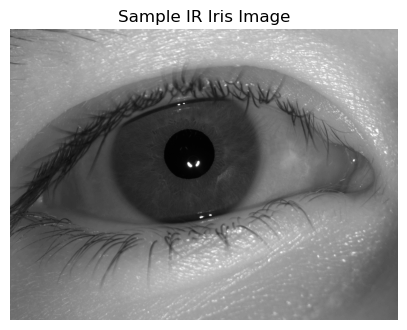

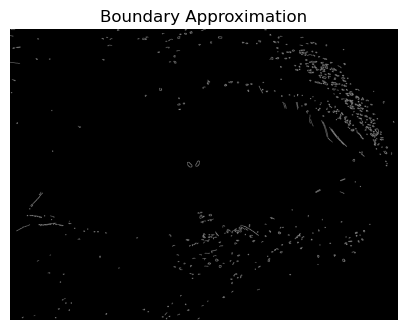

In [139]:
# ---- Imports ----
import cv2
import matplotlib.pyplot as plt

# ---- Load sample image ----
img_pixels = cv2.imread("./sample_ir_image.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(img_pixels, cmap='gray')
plt.title("Sample IR Iris Image")
plt.axis("off")

# ---- Boundary approximation ----
edges = cv2.Canny(img_pixels, 100, 200)

plt.figure(figsize=(5,5))
plt.imshow(edges, cmap="gray")
plt.title("Boundary Approximation")
plt.axis("off")

### What to look for

The `vectorization` stage converts segmentation masks into contour-based representations of the pupil, iris, and eyeball boundaries. The edge visualization above illustrates the type of boundary information that later nodes refine using interpolation, filtering, and smoothing.

| What you see | What it means|
|---|---|
| Boundary contours for parts of the eye.| Contours show boundaries for the pupil, iris, and eyeball, produced through vectorization. |